## Stroke Prediction EDA

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset
df = pd.read_csv('./data/healthcare-dataset-stroke-data_manipulated.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


### Basic Inspection of Data

In [3]:
df.shape

(4909, 12)

In [4]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4909 non-null   int64  
 1   gender             4909 non-null   str    
 2   age                4909 non-null   float64
 3   hypertension       4909 non-null   int64  
 4   heart_disease      4909 non-null   int64  
 5   ever_married       4909 non-null   str    
 6   work_type          4909 non-null   str    
 7   Residence_type     4909 non-null   str    
 8   avg_glucose_level  4909 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     4909 non-null   str    
 11  stroke             4909 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 460.3 KB


In [6]:
# drop id ccolumn
df = df.drop(columns='id')
df.sample()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2700,Male,24.0,0,0,No,Private,Urban,84.16,37.5,smokes,0


In [7]:
df.duplicated().sum()

np.int64(0)

### Target Variable Analysis

In [8]:
print(df['stroke'].value_counts())

stroke
0    3862
1    1047
Name: count, dtype: int64


In [9]:
# check percentage
print(round(df['stroke'].value_counts(normalize=True)*100, 2))

stroke
0    78.67
1    21.33
Name: proportion, dtype: float64


- **Dataset is imbalanced, 79% is No-stroke and 21% is stroke**

### Univariate Analysis

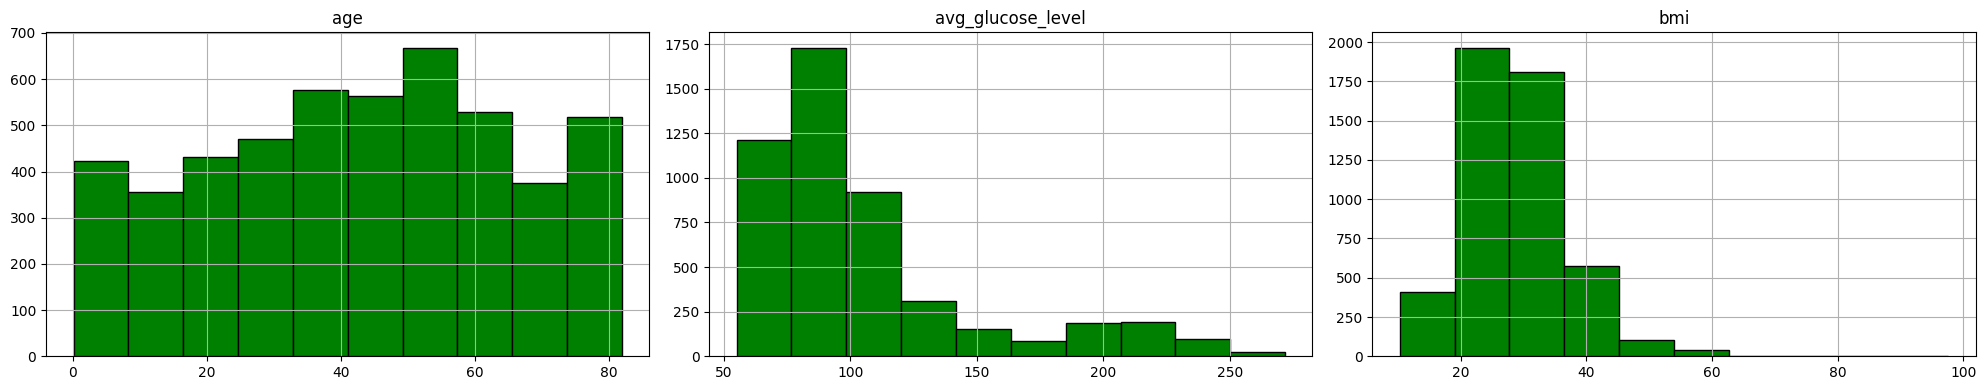

In [10]:
num_col = ['age' , 'avg_glucose_level' , 'bmi']
df[num_col].hist(bins = 10 , figsize=(20,4) , layout=(1,3) , edgecolor='black' ,
                 color = 'green')
# plt.title('Univariate Analysis')
plt.tight_layout()
plt.show()

<Axes: >

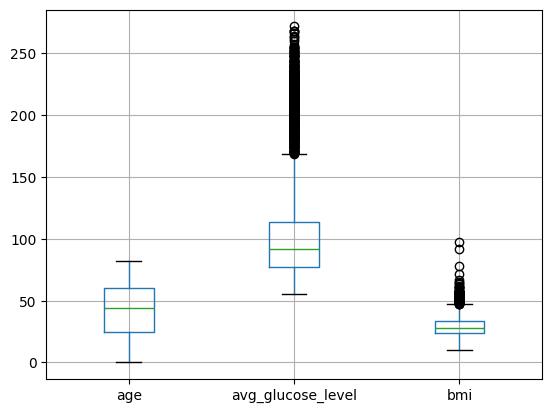

In [11]:
df[num_col].boxplot()

In [12]:
print(df['gender'].value_counts())
print(round(df['gender'].value_counts(normalize=True)*100))


gender
Female    2897
Male      2011
Other        1
Name: count, dtype: int64
gender
Female    59.0
Male      41.0
Other      0.0
Name: proportion, dtype: float64


In [13]:
# Always do this for proper bivariate analysis
print(round(df.groupby('hypertension')['stroke'].mean() * 100))


hypertension
0    15.0
1    79.0
Name: stroke, dtype: float64


In [14]:
# for every categorical column
for col in ['gender', 'hypertension', 'heart_disease', 'ever_married', 'smoking_status']:
    print(df.groupby(col)['stroke'].mean() * 100)
    print()

gender
Female     19.433897
Male       24.017902
Other     100.000000
Name: stroke, dtype: float64

hypertension
0    15.455361
1    79.379157
Name: stroke, dtype: float64

heart_disease
0    19.524218
1    55.967078
Name: stroke, dtype: float64

ever_married
No      9.325513
Yes    27.715356
Name: stroke, dtype: float64

smoking_status
Unknown            11.530681
formerly smoked    30.585424
never smoked       23.650108
smokes             24.694708
Name: stroke, dtype: float64



### Bivariate Analysis

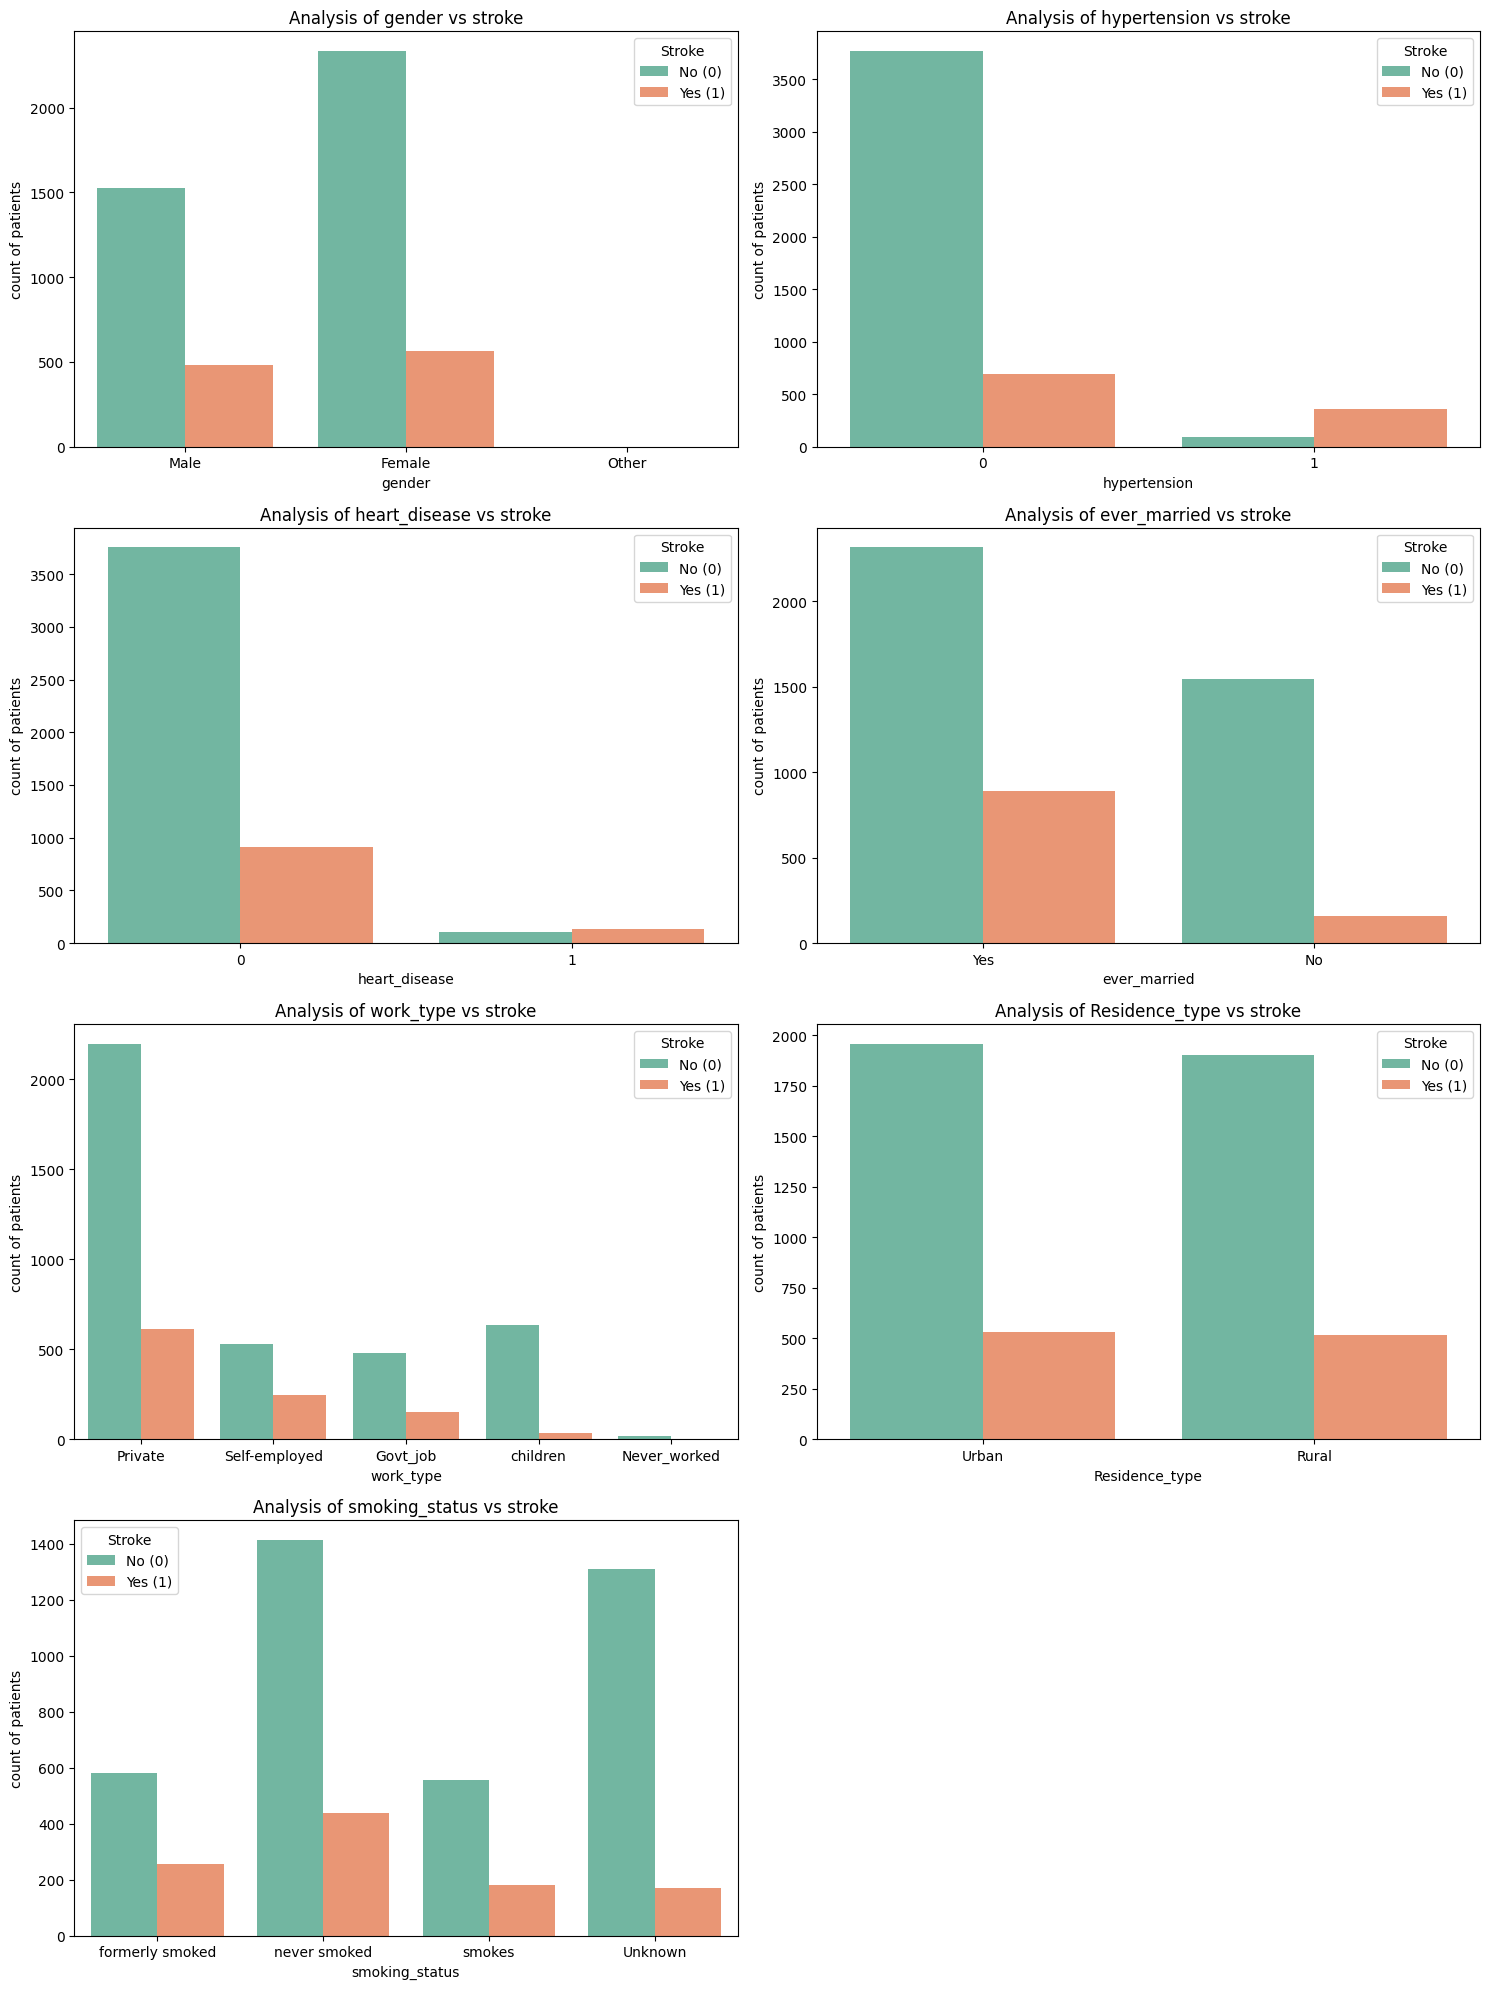

In [15]:
# categorical columns
cat_col = ['gender', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type',
       'smoking_status']

# figure size
plt.figure(figsize=(15,20))

for i,col in enumerate(cat_col , 1):
    plt.subplot(4 , 2 , i)

    sns.countplot(data=df, x= col , hue = 'stroke' , palette='Set2')

    plt.title(f"Analysis of {col} vs stroke")
    plt.xlabel(col)
    plt.ylabel("count of patients")
    plt.xticks()
    plt.legend(title='Stroke', labels=['No (0)', 'Yes (1)'])

    plt.tight_layout()
#     plt.show()


* **Hypertension** and **Heart Disease** are the biggest reasons of Stroke
* **Married** people face more Stroke then unmarried... old age can be the main reason
* **Gender** and **residence_type** does not have any significant impact on Stroke rate
* People who have **stopped smaoking** has more chances of stroke than currently smoking

### Correlation Analysis

                        age  hypertension  heart_disease  avg_glucose_level  \
age                1.000000      0.274425       0.257123           0.235838   
hypertension       0.274425      1.000000       0.115991           0.180543   
heart_disease      0.257123      0.115991       1.000000           0.154525   
avg_glucose_level  0.235838      0.180543       0.154525           1.000000   
bmi                0.333398      0.167811       0.041357           0.175502   
stroke             0.363111      0.450756       0.192978           0.716379   

                        bmi    stroke  
age                0.333398  0.363111  
hypertension       0.167811  0.450756  
heart_disease      0.041357  0.192978  
avg_glucose_level  0.175502  0.716379  
bmi                1.000000  0.195772  
stroke             0.195772  1.000000  


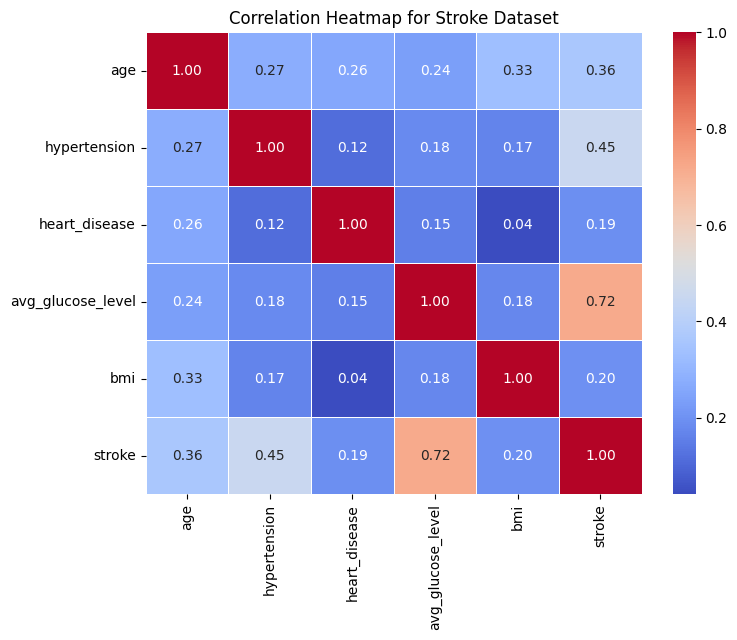

In [16]:
import numpy as np
# select numerical columns
numerical_df = df[['age', 'hypertension', 'heart_disease', 
                   'avg_glucose_level', 'bmi', 'stroke']]

# 2. Correlation matrix
corr_matrix = numerical_df.corr()
print(corr_matrix)

# 3. Heatmap
plt.figure(figsize=(8, 6))
# annot=True(numbers inside box), cmap = setcolor theme
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap for Stroke Dataset")
plt.show()



| Feature | Correlation with Stroke | Meaning |
|---|---|---|
| avg_glucose_level | **0.72** | Strongest numerical predictor |
| hypertension | **0.45** | Second strongest |
| age | **0.36** | Meaningful |
| bmi | **0.20** | Weak |
| heart_disease | **0.19** | Weak here, but rate analysis showed it matters |

---

**One extra observation , avg_glucose vs stroke = 0.72**

This is surprisingly high. High glucose = diabetic or pre-diabetic = much higher stroke risk. Makes complete medical sense.

---

**Between features (not stroke):**

- age & hypertension = **0.27** → older people tend to have hypertension, expected
- age & bmi = **0.33** → older people slightly higher BMI
- Everything else is low — no serious multicollinearity problem

#### Top 3 numerical predictors in order:
1. avg_glucose_level
2. age  
3. BMI (weakest)



---
# **Model Training**

## Preprocessing Steps

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_col = df.select_dtypes(include='object')
for col in categorical_col:
    df[col] = le.fit_transform(df[col])

# split features and target
X = df.drop('stroke' , axis = 1)
y = df['stroke']

# Train,Test, Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.20 , 
                                                    random_state=42)


C:\Users\HP\AppData\Local\Temp\ipykernel_19588\907991697.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include='object')


### Train Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)



c:\Users\HP\miniconda3\envs\python_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [28]:
# prediction
y_pred = model.predict(X_test)


# Evaluation
print(f"precision Score(lr):" , precision_score(y_test, y_pred))
print(f"Recall Score(lr):" , recall_score(y_test, y_pred))
print(f"F1 Score(lr):" , f1_score(y_test, y_pred))
print(f"Accurcy  Score(lr):" , accuracy_score(y_test, y_pred))


precision Score(lr): 0.7860082304526749
Recall Score(lr): 0.8642533936651584
F1 Score(lr): 0.8232758620689655
Accurcy  Score(lr): 0.9164969450101833


### S-Shaped Graph

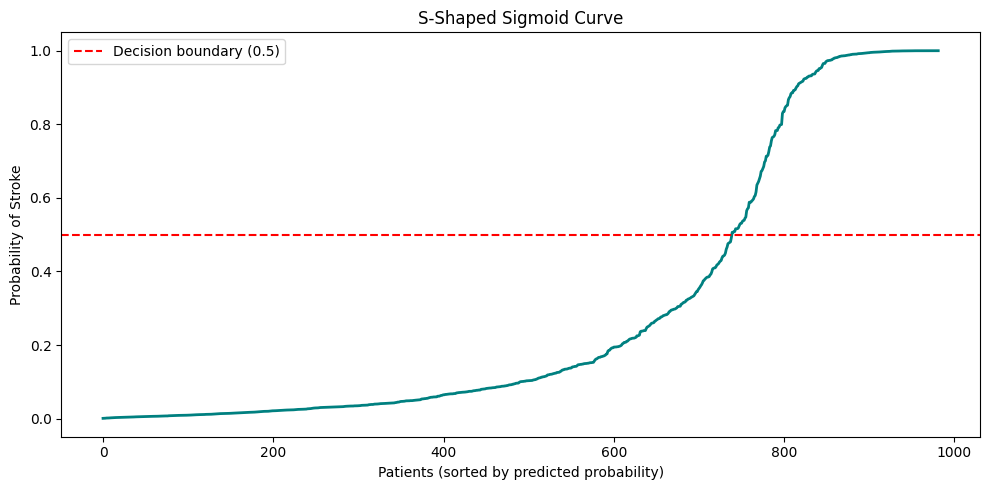

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# get predicted probabilities (not just 0/1)
y_proba = model.predict_proba(X_test)[:, 1] # .predict_proba gives probabilities

# sort by probability for clean S shape
sorted_idx = np.argsort(y_proba)

plt.figure(figsize=(10, 5))
plt.plot(y_proba[sorted_idx], color='teal', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Decision boundary (0.5)')
plt.title("S-Shaped Sigmoid Curve")
plt.xlabel("Patients (sorted by predicted probability)")
plt.ylabel("Probability of Stroke")
plt.legend()
plt.tight_layout()
plt.show()

### **Key Insights from the Sigmoid Curve**

* **Visualizing Data Imbalance:** The very long flat line at the bottom shows that the majority of patients (~79%) are at near-zero risk. The curve shoots up sharply only at the end, representing the high-risk minority group.
* **Probability vs. Decisions:** Instead of just outputting 0 or 1, this curve tracks the exact risk percentage (0% to 100%) for every single patient in the test set.
* **The Decision Cutoff:** The red dashed line at **0.5** is the model's boundary. Anyone below this line is predicted as 'No Stroke', and anyone climbing above it is classified as 'Stroke'.
* **Perfect Risk Sorting:** Sorting the patients from lowest to highest risk using `np.argsort()` is what allows us to see this clean, continuous S-shape instead of scattered points.

---
## Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

model1 = DecisionTreeClassifier(class_weight= 'balanced' , random_state=42)
model1.fit(X_train , y_train)

y1_pred = model1.predict(X_test)

print(f"precision Score(dt):" , precision_score(y_test, y1_pred))
print(f"Recall Score(dt):" , recall_score(y_test, y1_pred))
print(f"F1 Score(dt):" , f1_score(y_test, y1_pred))
print(f"Accurcy  Score(dt):" , accuracy_score(y_test, y1_pred))
print("-"*20)
print(classification_report(y_test , y1_pred))

precision Score(dt): 0.8858447488584474
Recall Score(dt): 0.8778280542986425
F1 Score(dt): 0.8818181818181818
Accurcy  Score(dt): 0.9470468431771895
--------------------
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       761
           1       0.89      0.88      0.88       221

    accuracy                           0.95       982
   macro avg       0.93      0.92      0.92       982
weighted avg       0.95      0.95      0.95       982



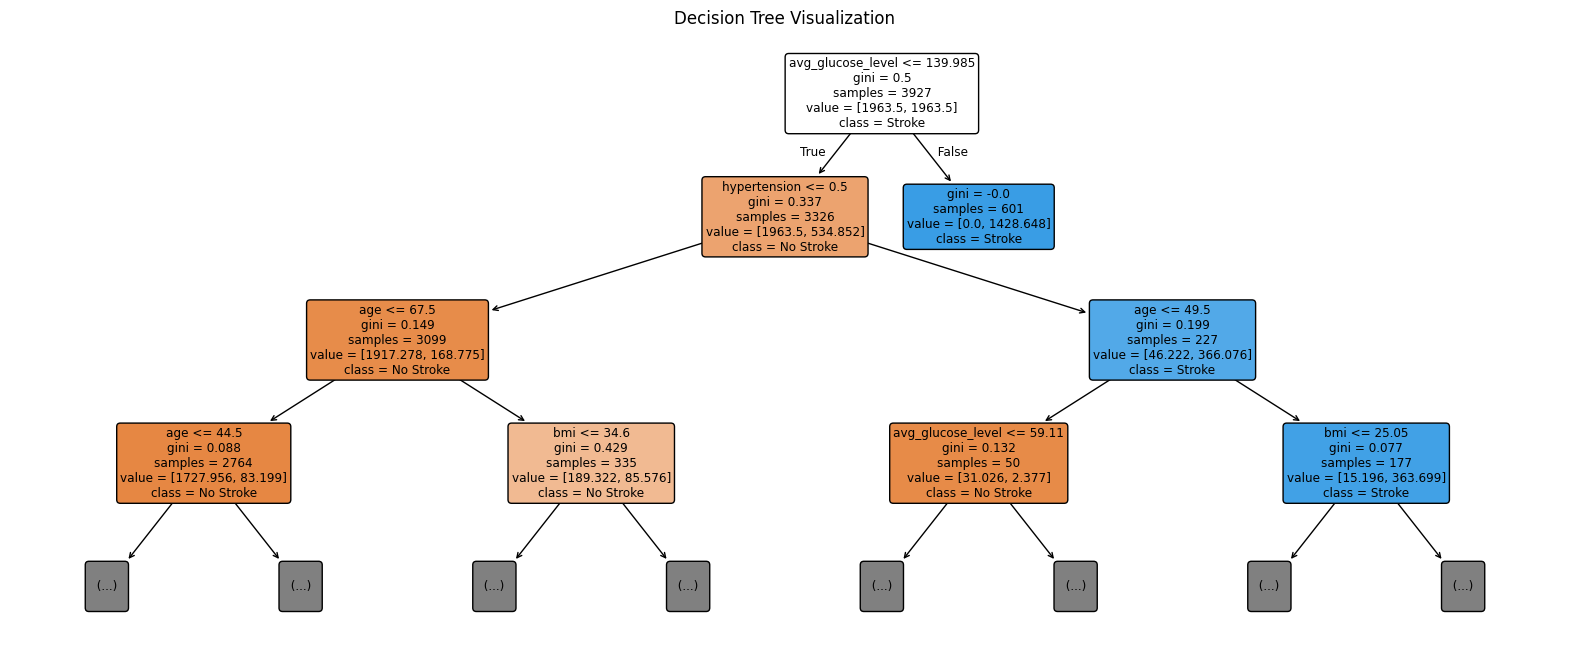

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
plot_tree(model1, 
          feature_names=X.columns.tolist(), 
          class_names=['No Stroke', 'Stroke'],
          filled=True,       # colors the nodes
          rounded=True,      # rounded boxes
          max_depth=3)       # limit depth so it's readable
plt.title("Decision Tree Visualization")
plt.show()


### **Decision Tree Visualization Insights**

* **Top Split (Root Node):** The model identifies `avg_glucose_level` as the single most critical factor for predicting stroke risk.
* **High Sugar Risk:** Patients with an average glucose level greater than **139.98** (Right/False branch) are immediately classified into the high-risk **Stroke** category, matching our initial correlation analysis ($0.72$).
* **Lower Sugar Path:** For patients with glucose levels below 139.98, the model filters further based on **Hypertension** and **Age**. Younger patients with normal blood pressure consistently fall into the safe **No Stroke** category.
* **Tree Efficiency:** As the path moves lower, the `gini` impurity drops significantly toward `0.0`, indicating that the model successfully purifies the data into distinct, reliable patient risk groups at the leaf nodes.

## Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
model2.fit(X_train, y_train)

y2_pred = model2.predict(X_test)

print(f"precision Score(rf):" , precision_score(y_test, y2_pred))
print(f"Recall Score(rf):" , recall_score(y_test, y2_pred))
print(f"F1 Score(rf):" , f1_score(y_test, y2_pred))
print(f"Accurcy  Score(rf):" , accuracy_score(y_test, y2_pred))
print("-"*20)
print(classification_report(y_test, y2_pred))

precision Score(rf): 0.9896907216494846
Recall Score(rf): 0.8687782805429864
F1 Score(rf): 0.9253012048192771
Accurcy  Score(rf): 0.9684317718940937
--------------------
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       761
           1       0.99      0.87      0.93       221

    accuracy                           0.97       982
   macro avg       0.98      0.93      0.95       982
weighted avg       0.97      0.97      0.97       982



## Feature Importance

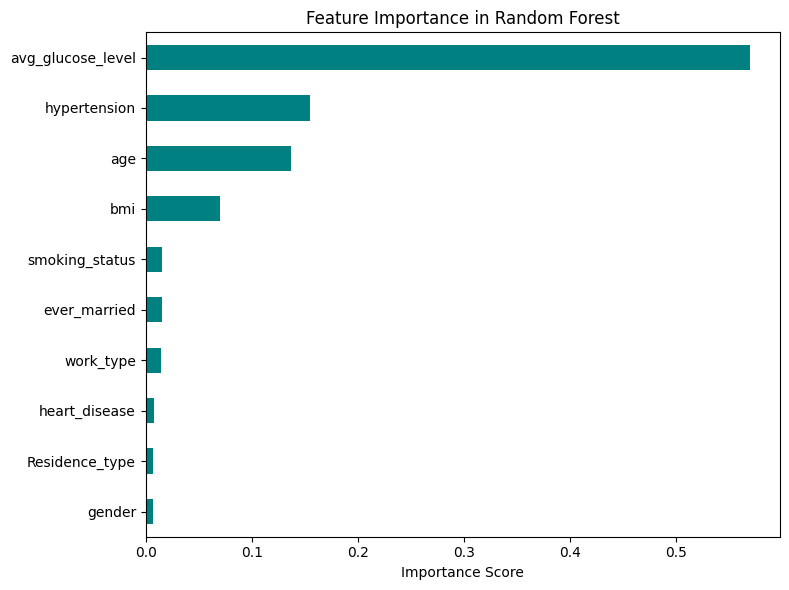

In [24]:
import pandas as pd

importance = pd.Series(model2.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

importance.plot(kind='barh', figsize=(8, 6), color='teal')
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Model Comparison Table



In [25]:
print("="*50)
print("MODEL COMPARISON")
print("="*50)

models = {
    'Logistic Regression': y_pred,
    'Decision Tree': y1_pred,
    'Random Forest': y2_pred
}

for name, pred in models.items():
    print(f"\n{name}")
    print(f"  Accuracy : {accuracy_score(y_test, pred):.2f}")
    print(f"  Precision: {precision_score(y_test, pred):.2f}")
    print(f"  Recall   : {recall_score(y_test, pred):.2f}")
    print(f"  F1 Score : {f1_score(y_test, pred):.2f}")

MODEL COMPARISON

Logistic Regression
  Accuracy : 0.92
  Precision: 0.79
  Recall   : 0.86
  F1 Score : 0.82

Decision Tree
  Accuracy : 0.95
  Precision: 0.89
  Recall   : 0.88
  F1 Score : 0.88

Random Forest
  Accuracy : 0.97
  Precision: 0.99
  Recall   : 0.87
  F1 Score : 0.93


## Save the model (Decision Tree)

In [30]:
import joblib
joblib.dump(model1 , 'model_dt.pkl')

print("model saved!")

model saved!
